In [39]:
%config InlineBackend.figure_format = 'retina'

import os
from pathlib import Path

import numpy as np


import matplotlib.pyplot as plt


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def exact_population(theta, x, A, gamma):
    return np.exp(-A * x * np.exp(gamma * theta))


def sigmoid_population(theta, x, A, gamma):
    gamma_sig = 4.0 * gamma / np.e
    beta_sig = np.log(np.exp(-1.0) / (1.0 - np.exp(-1.0)))
    theta_hat = -(np.log(A) + np.log(x)) / gamma
    return sigmoid(-gamma_sig * (theta - theta_hat)+beta_sig)


def exact_single_unit(x, theta_i, A, gamma):
    lam = A * np.exp(gamma * theta_i)
    return np.exp(-lam * x)


def sigmoid_single_unit(x, theta_i, A, gamma):
    p = np.e / (np.e - 1.0)
    lam = A * np.exp(gamma * theta_i)
    return 1.0 / (1.0 + (np.e - 1.0) * (lam * x) ** p)




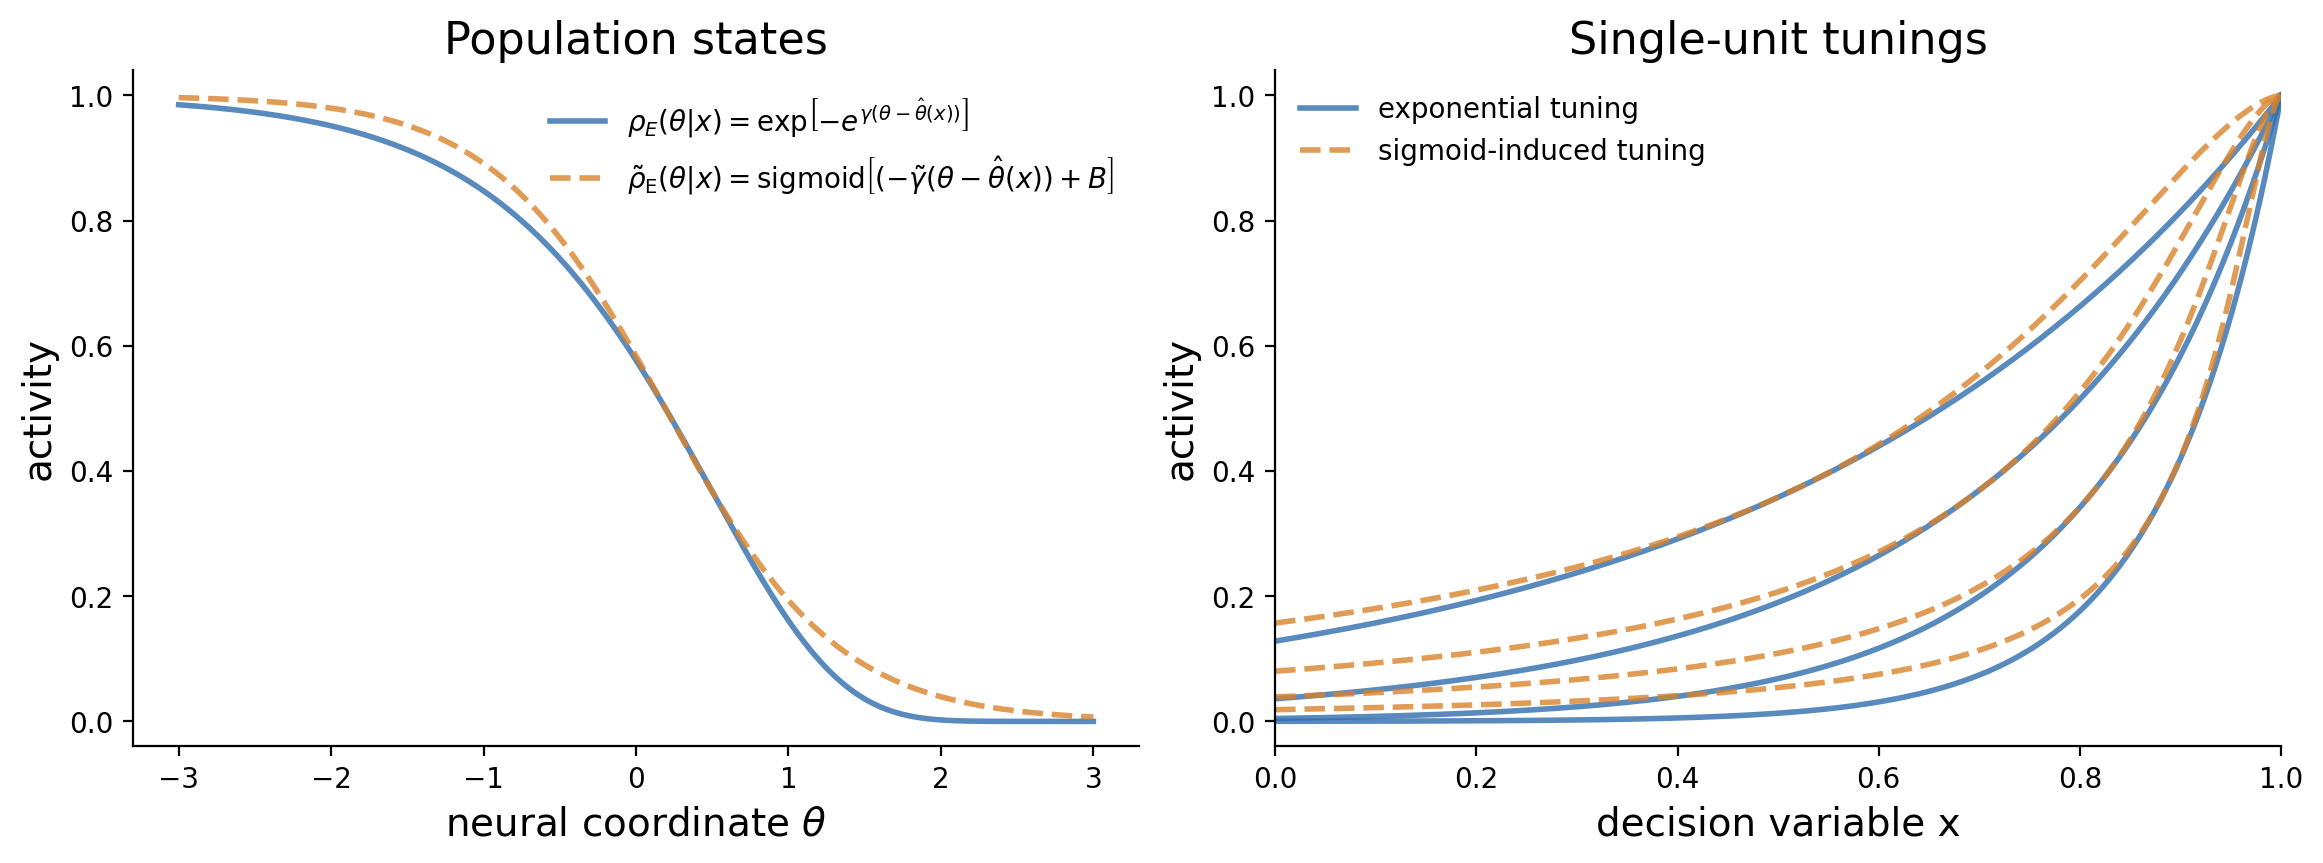

In [54]:

# A visually useful configuration: all example edge locations fall within
# the plotted neural coordinate range.
A = 1.0
gamma = 1.2

theta = np.linspace(-3.0, 3.0, 900)
x_states = [0.55]

x = np.linspace(0.0, 1.0, 900)
theta_units = [0.6, 1, 1.4, 1.8]

exact_color = "#2F6DAE"
sigmoid_color = "#D9822B"
fontsize = 14

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)

ax = axes[0]
for j, x0 in enumerate(x_states):
    alpha = 0.8
    ax.plot(
        theta,
        exact_population(theta, x0, A, gamma),
        color=exact_color,
        lw=2.0,
        alpha=alpha,
        label=r"$\rho_E(\theta|x)= \exp\!\left[-e^{\gamma(\theta-\hat{\theta}(x))}\right]$" if j == 0 else None,
    )
    ax.plot(
        theta,
        sigmoid_population(theta, x0, A, gamma),
        color=sigmoid_color,
        lw=2.0,
        ls="--",
        alpha=alpha,
        label=r"$\tilde{\rho}_{\text{E}}(\theta|x) = \mathrm{sigmoid}\left[(-\tilde{\gamma}(\theta-\hat{\theta}(x))+B\right]$" if j == 0 else None,
    )
    theta_hat = -(np.log(A) + np.log(x0)) / gamma
    # ax.text(
    #     theta_hat,
    #     0.06,
    #     f"x={x0:g}",
    #     ha="center",
    #     va="bottom",
    #     fontsize=8,
    #     color="0.25",
    #     rotation=90,
    # )

ax.set_title("Population states", fontsize=16)
ax.set_xlabel(r"neural coordinate $\theta$", fontsize=14)
ax.set_ylabel("activity", fontsize=14)
ax.set_ylim(-0.04, 1.04)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right")

ax = axes[1]
for j, theta_i in enumerate(theta_units):
    alpha = 0.8
    ax.plot(
        x,
        exact_single_unit(x, theta_i, A, gamma)[::-1],
        color=exact_color,
        lw=2.0,
        alpha=alpha,
        label="exponential tuning" if j == 0 else None,
    )
    ax.plot(
        x,
        sigmoid_single_unit(x, theta_i, A, gamma)[::-1],
        color=sigmoid_color,
        lw=2.0,
        ls="--",
        alpha=alpha,
        label="sigmoid-induced tuning" if j == 0 else None,
    )

    lam = A * np.exp(gamma * theta_i)
    x_mid = min(0.96, 1.0 / lam)
    y_mid = exact_single_unit(x_mid, theta_i, A, gamma)
    # ax.text(
    #     x_mid,
    #     y_mid + 0.05,
    #     rf"$\theta_i={theta_i:g}$",
    #     ha="center",
    #     va="bottom",
    #     fontsize=8,
    #     color="0.25",
    # )

ax.set_title("Single-unit tunings", fontsize=16)
ax.set_xlabel("decision variable x", fontsize=14)
ax.set_ylabel("activity", fontsize=14)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-0.04, 1.04)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")

# fig.suptitle(
#     rf"Sigmoid edge approximation ($A={A:g}$, $\gamma={gamma:g}$, "
#     rf"$\gamma_\sigma=4\gamma/e$)",
#     fontsize=12,
# )


<!-- #!/usr/bin/env python3
"""Plot population- and single-unit-level sigmoid edge approximations.

The exact edge profile induced by exponential single-unit tunings is

   $$ \rho(\theta | x) = \exp[-A x \exp(\gamma \theta)]$$

Writing theta_hat(x) = -(\log A + \log x) / \gamma gives

  $$ \rho(\theta | x) = \exp[-\exp(\gamma (\theta -\hat{\theta}}))]. $$

The manuscript approximates this translated edge family by a sigmoid edge whose
maximal local slope matches the exact edge:

 $$   \rho_{\sigma}(\theta | x) = \sigma[-\gamma_{\sigma} (\theta - \hat{\theta}}],
    gamma_sig = 4 gamma / e.

At the single-unit level, for \lambda_i = A e^{\gamma \theta_i}, this corresponds
to comparing e^{-lambda_i x} with 1 / (1 + (\lambda_i x)^(4/e)). -->
"""
